# HW 4 — From Scratch: Reconstruct an Impossible Object
**Modern Computer Vision** — Technion, Spring 2026

**Due:** July 22, 2026

## Submission Requirements

**IMPORTANT:** Submit this notebook **with all outputs** — run all cells before submitting. Notebooks without outputs will lose points. Make sure your `STUDENT_ID` is set correctly.

**Student ID:**

In [1]:
STUDENT_ID = ""  # <-- Fill in your student ID

---
## The mission

You've surely seen the famous **impossible triangle**. It can't exist as a solid object... yet a clever sculptor built one, and **Photo 1 below shows it looking genuinely impossible**. Photo 2, shot from another spot, gives the game away: three loose beams that never actually touch.

So which is real? From just these **two photos** you will recover, **from scratch with NumPy**, both *where the two cameras were* and *the true 3-D shape* — and see for yourself how three separate beams can masquerade as the impossible.

The cameras are **calibrated** (intrinsics `K = I`), which buys us a beautiful simplification: the **fundamental matrix is already the essential matrix**. So the whole pipeline is just five short functions, which are the only things you implement:

| function | what it does |
|---|---|
| `detect_corners` | find corners in a photo (Harris / Shi-Tomasi) |
| `eight_point` | the essential matrix `E` from point matches |
| `decompose_E` | the four candidate camera poses hidden in `E` |
| `triangulate` | 3-D points from two known cameras |
| `recover_pose` | pick the one physically real pose |

Everything else — the scene, the photos, the mouse matcher, the plots, the 3-D viewer — is provided in `penrose_utils.py`. You'll write about 40 lines of NumPy in total.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from penrose_utils import (make_cameras, project, normalize_pts,
                           show_views, view_images, smooth, corner_peaks, show_detections,
                           pick_points, DEFAULT_PICKS,
                           show_correspondences, show_epipolar_lines, similarity_align,
                           visible_corner_views, visible_corner_truth, visible_corner_colors,
                           show_point_cloud, corner_truth, enumerate_faces, show_surfaces)
np.set_printoptions(suppress=True, precision=4)
%matplotlib inline

---
## The two photos

**Photo 1** is taken from near the sculptor's magic angle — it really looks like a solid impossible triangle. **Photo 2** is an ordinary oblique view, and the trick collapses into three floating beams. Because the cameras sit in different places, each corner lands somewhere different in the two photos (**parallax**) — and that difference is exactly what we triangulate into depth.

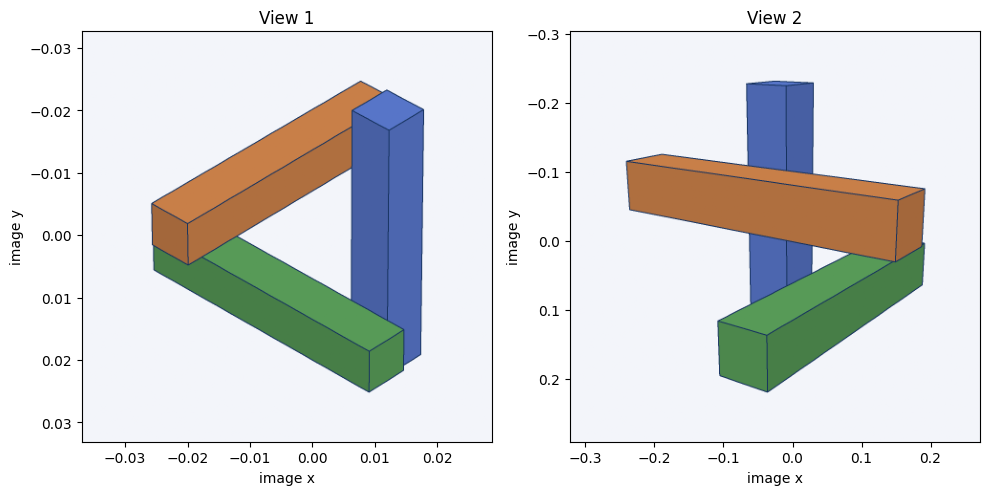

In [3]:
show_views()

---
## Step 1 — Detect corners (Harris)

Geometry starts from **point correspondences**, and to match points we first have to *find* them. The classic tool is the **Harris / Shi-Tomasi corner detector**: at each pixel it looks at the local gradients and asks *“does the image change in two different directions here?”* — true only at **corners**, not along edges or on flat regions. (Flat shading is why the blank beam faces give nothing to detect — only the corners do.)

Implement `detect_corners` (the helpers `smooth` and `corner_peaks` — windowing and non-max suppression — are provided):

In [4]:
def detect_corners(image, sigma=2.0, thresh=0.02):
    """Harris / Shi-Tomasi corner detector. Returns (M, 2) corner pixels (x, y).

    The structure tensor of a window is  M = [[Sigma Ix^2, Sigma IxIy],
    [Sigma IxIy, Sigma Iy^2]]. A corner is where BOTH eigenvalues of M are large;
    we use the SMALLER eigenvalue as the corner strength (the Shi-Tomasi measure).

    Steps (the helpers `smooth` and `corner_peaks` are provided):
      1. grayscale = image.mean(2);  pre-smooth it a little: g = smooth(gray, 1.2)
      2. gradients:  Iy, Ix = np.gradient(g)
      3. structure-tensor sums (each a smoothed product of gradients):
             Sxx = smooth(Ix*Ix, sigma);  Syy = smooth(Iy*Iy, sigma);  Sxy = smooth(Ix*Iy, sigma)
      4. smaller eigenvalue of [[Sxx,Sxy],[Sxy,Syy]] as the response:
             tr = Sxx+Syy;  det = Sxx*Syy - Sxy**2;  R = 0.5*(tr - np.sqrt(tr**2 - 4*det))
      5. return corner_peaks(R, thresh)   # provided: threshold + non-max suppression + sub-pixel
    """
    # TODO [core] -- implement using the hints above
    raise NotImplementedError("detect_corners")

Run it on both photos and look at what it found:

In [ ]:
img1, img2 = view_images()           # the two photos, as RGB arrays
c1 = detect_corners(img1)            # corner pixels in photo 1
c2 = detect_corners(img2)            # corner pixels in photo 2
print(f'detected {len(c1)} and {len(c2)} corners')
show_detections(c1, c2)

---
## Step 2 — Match the corners (and throw out the fakes)

The detector finds *image* corners — but some of them are **occlusion junctions**: places where one beam merely crosses *in front of* another. Those look like corners but are **not real 3-D points** (they have no match in the other view), and matching one would poison the geometry. So your job is two-fold:

- **Match** a real corner in View 1 to the same corner in View 2 (click one, then the other). Pick **≥ 8**, spread over the beams.
- **Mark junk:** switch to *marking* mode and click any detection that is *not* a real corner — a spot where two **different-coloured** beams merely cross — to grey it out. (A real corner belongs to a *single* beam.)

When you have ≥ 8 clean matches, press **📋 Copy picks** and paste the line below.

In [ ]:
pick_points(c1, c2)

In [ ]:
# Paste your picks from the tool above here (overwrite this line).
# Or just run as-is: DEFAULT_PICKS is a ready-made reference set so the rest of
# the notebook works even before you've matched your own.
picks = DEFAULT_PICKS

p1 = picks[:, :2]   # (N,2) corners in view 1
p2 = picks[:, 2:]   # (N,2) matching corners in view 2
print(f'{len(picks)} correspondences')

Sanity check — your matches, drawn on both photos. Matching numbers should sit on the **same corner** in each view:

In [ ]:
show_correspondences(picks)

---
## Step 3 — The essential matrix `E`

`E` is the single 3×3 matrix that ties the two views together. For matching points $x_1,x_2$ (homogeneous, in the calibrated frame) it obeys the **epipolar constraint**

$$x_2^{\top}\,E\,x_1 = 0.$$

Each correspondence turns this into **one linear equation** in the 9 entries of `E`; with 8+ matches we solve for the null space by SVD. A real essential matrix is special — it has singular values $(1,1,0)$ — so we finish by projecting onto that form.

Implement `eight_point` (it may call the provided `normalize_pts`):

In [ ]:
def eight_point(p1, p2):
    """Essential matrix E from >= 8 correspondences.

    The cameras are calibrated to K = I, so the fundamental matrix IS the
    essential matrix -- the classic 8-point algorithm gives E directly. Every
    correspondence satisfies the epipolar constraint   [p2;1]^T E [p1;1] = 0.

    Args:    p1, p2 : (N,2) matching image points, N >= 8.
    Returns: E : (3,3) with singular values (1, 1, 0).

    Steps / hints
      1. pre-condition the points:  x1,T1 = normalize_pts(p1);  x2,T2 = normalize_pts(p2)
      2. each match (x,y)<->(a,b) is one row of an (N,9) matrix A:
             [a*x, a*y, a,  b*x, b*y, b,  x, y, 1]
      3. solve A e = 0  ->  e is the last row of Vt in np.linalg.svd(A); reshape to (3,3)
      4. undo the normalization:  E = T2.T @ E @ T1
      5. project onto a valid essential matrix: SVD it, rebuild with singular values (1,1,0)
    """
    # TODO [core] -- implement using the hints above
    raise NotImplementedError("eight_point")

Sanity check — the epipolar residual should be essentially zero, and every View-2 point should land on its **epipolar line**:

In [ ]:
E = eight_point(p1, p2)
res = np.abs([np.r_[b, 1] @ E @ np.r_[a, 1] for a, b in zip(p1, p2)]).mean()
print(f'mean epipolar residual: {res:.2e}   (should be ~1e-10 or smaller)')
assert res < 1e-6, 'E does not satisfy the epipolar constraint — check eight_point'
show_epipolar_lines(E, picks)

---
## Step 4 — Recover the two camera poses

`E` secretly contains the **relative pose** between the cameras — but with a four-fold ambiguity (two rotations × two translation signs), and the translation only up to scale. We pull out all four candidates from the SVD of `E` (`decompose_E`), and triangulate points (`triangulate`) to test each one. Only the true pose puts the scene **in front of both cameras** — the **cheirality** test in `recover_pose` selects it.

Implement the three functions:

In [ ]:
def decompose_E(E):
    """The four candidate relative poses (R, t) encoded by E.

    Args:    E : (3,3).
    Returns: a list of four (R, t):  R is a (3,3) rotation, t is a (3,) unit vector.

    Hints
      - U, S, Vt = np.linalg.svd(E). Force U and Vt to be proper rotations:
        if det(U) < 0 negate U; if det(Vt) < 0 negate Vt.
      - W = [[0,-1,0],[1,0,0],[0,0,1]].
      - the two possible rotations are  U @ W @ Vt  and  U @ W.T @ Vt.
      - the translation is  +U[:,2]  or  -U[:,2].
      - return all four (rotation, translation) combinations.
    """
    # TODO [core] -- implement using the hints above
    raise NotImplementedError("decompose_E")

In [ ]:
def triangulate(P1, P2, x1, x2):
    """Linear (DLT) triangulation of points seen in two cameras.

    Args:    P1, P2 : (3,4) camera matrices (here P = [R | t], since K = I);
             x1, x2 : (N,2) matching image points.
    Returns: X : (N,3) triangulated 3-D points.

    Hints
      - a point (a, b) seen by camera P gives two linear equations in X (homogeneous):
            a * P[2] - P[0]   and   b * P[2] - P[1]
      - stack the 2 rows from each camera into a 4x4 matrix A; the solution is the
        last row of Vt in np.linalg.svd(A); divide by its 4th entry to dehomogenize.
    """
    # TODO [core] -- implement using the hints above
    raise NotImplementedError("triangulate")

In [ ]:
def recover_pose(E, x1, x2):
    """Pick the physically correct (R, t) from E's four candidates.

    Three of the four put points behind a camera; the real one puts them in
    FRONT of both ("cheirality"). Set camera 1 = [I | 0] and camera 2 = [R | t],
    triangulate, and keep the candidate with the most positive-depth points.

    Args:    E : (3,3);  x1, x2 : (N,2) matching points.
    Returns: (R, t) -- the chosen rotation and unit translation.

    Hints
      - depth in camera 1 is  X[:, 2].
      - depth in camera 2 is  (R @ X.T + t[:, None])[2].
      - count points with positive depth in BOTH; take the argmax over the 4 candidates.
    """
    # TODO [core] -- implement using the hints above
    raise NotImplementedError("recover_pose")

Sanity checks — each function on its own, then the recovered pose against the true camera motion:

In [ ]:
# (a) triangulate recovers a known 3-D point from two known cameras
P1t = np.eye(3, 4); P2t = np.c_[np.eye(3), [-1., 0, 0]]   # camera 2 shifted 1 unit in x
Xtrue = np.array([[0.2, -0.1, 4.0]])
xa = P1t @ np.r_[Xtrue[0], 1]; xb = P2t @ np.r_[Xtrue[0], 1]
Xest = triangulate(P1t, P2t, (xa[:2]/xa[2])[None], (xb[:2]/xb[2])[None])
assert np.allclose(Xest, Xtrue, atol=1e-9); print('\u2713 triangulate')

# (b) decompose_E returns four proper rotations
for R, t in decompose_E(E):
    assert np.allclose(R @ R.T, np.eye(3), atol=1e-6) and np.isclose(np.linalg.det(R), 1, atol=1e-6)
print('\u2713 decompose_E (4 valid rotations)')

# (c) recover_pose matches the TRUE relative motion between the two cameras
R1, t1, R2, t2 = make_cameras()
R, t = recover_pose(E, p1, p2)
R_rel = R2 @ R1.T
ang = np.degrees(np.arccos(np.clip((np.trace(R @ R_rel.T) - 1) / 2, -1, 1)))
print(f'\u2713 recover_pose: rotation error {ang:.3f}\u00b0')
assert ang < 1.0, 'recovered rotation is off — check decompose_E / recover_pose'

---
## Step 5 — Triangulate the corners → a point cloud

With both cameras known ($P_1=[I\,|\,0]$, $P_2=[R\,|\,t]$), any matched corner is just two rays intersected. You can only triangulate a corner you can **see in both photos** — so this gives the corners that are visible in both views (a corner hidden behind a beam in either photo has nothing to triangulate from). Your `triangulate` lifts them into 3-D.

Two photos alone can't fix the **absolute size** of the world (a small object up close looks like a big one far away), so the reconstruction is correct only up to a **similarity** (scale + rotation + position). We line it up with the truth to score it.

The result is a **sparse point cloud** of the corners you could see. Drag it around (the slider sets dot size):

In [ ]:
R, t = recover_pose(E, p1, p2)
P1 = np.eye(3, 4)
P2 = np.c_[R, t]

xv1, xv2 = visible_corner_views()             # corners visible (hence matchable) in BOTH photos
cloud = triangulate(P1, P2, xv1, xv2)         # your cameras + your triangulation

truth = visible_corner_truth()
cloud = similarity_align(cloud, truth)         # fix the scale/pose freedom
err = np.linalg.norm(cloud - truth, axis=1)
size = np.linalg.norm(truth.max(0) - truth.min(0))
print(f'reconstructed {len(cloud)} corners (the ones visible in both photos)')
print(f'median error: {np.median(err) / size * 100:.3f}% of object size')
show_point_cloud(cloud, visible_corner_colors())

---
## Step 6 — From points to surfaces 🔺

Here's the honest catch: two photos of a sparse set of corners give you the **cameras** and **those corners** — but *not* the corners hidden in both photos, and *not* the surfaces. A point cloud has no faces, and you can't invent the hidden corners from thin air. Both can come from only one thing: **knowing what the object is**.

And we do know it — three solid beams. That model supplies the **hidden corners** and the **18 planar faces** (3 beams × 6 faces). Locking that model into the frame *your* reconstruction recovered gives the full solid. So: **the cameras and the visible corners are genuinely yours**; the beam *model* is the one prior we bring. Drag and orbit — from almost every angle it's three beams floating apart, but at one direction they snap into the impossible triangle, **the very angle Photo 1 was taken from**.

In [ ]:
faces = enumerate_faces()        # (18, 4) — the 18 planar faces of the known 3-beam model
print(f'{len(faces)} planar faces')
show_surfaces(corner_truth(), faces)   # the known beam model, in the frame your reconstruction recovered

---
*Modern Computer Vision — Technion — Spring 2026*